# TriHydrA Layer 3: nearby-gauge context prototype

This notebook does four things:

1. Loads the 883-gauge outlet metadata.
2. Plots all gauges and creates one interactive local map for each target station.
3. Selects same-catchment and same-river comparison candidates.
4. Validates whether the row order of `caravan_observations.nc` matches `outlets_all_systems.csv` using the three known target CSV files, then compares target and candidate discharge statistics.

## Projection

The station coordinates are longitude/latitude in **WGS 84 (`EPSG:4326`)**. Folium expects latitude and longitude directly and displays them on web-map tiles using Web Mercator internally. Do not manually convert the coordinates for the interactive map.

Distances are calculated with the **Haversine great-circle formula**, so no local projected CRS is needed for this global dataset.


In [1]:
# Run this only if folium is not already installed.
%pip install folium -q

Note: you may need to restart the kernel to use updated packages.


In [1]:


from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import folium

from folium.plugins import MarkerCluster
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# FILE PATHS
# Keep the files beside this notebook, or replace these paths.
# ------------------------------------------------------------------
OUTLETS_PATH = Path("outlets_all_systems.csv")
STATIC_PATH = Path("static_attributes_filtered.csv")
NC_PATH = Path("caravan_observations.nc")

TARGET_FILES = {
    "GRDC_4123300": Path("GRDC_4123300_streamflow_data.csv"),
    "GRDC_5304140": Path("GRDC_5304140_streamflow_data.csv"),
    "GRDC_6341500": Path("GRDC_6341500_streamflow_data.csv"),
}

OUTPUT_DIR = Path("layer3_context_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_IDS = list(TARGET_FILES)
TARGET_IDS


['GRDC_4123300', 'GRDC_5304140', 'GRDC_6341500']

## 1. Load and prepare station metadata

`outlets_all_systems.csv` supplies the catchment, river, station name and outlet coordinates.  
`static_attributes_filtered.csv` supplies the preferred catchment area where available.


In [3]:
outlets = pd.read_csv(OUTLETS_PATH).copy()
outlets["outlet_row_index"] = np.arange(len(outlets))

static = (
    pd.read_csv(STATIC_PATH, usecols=["basin", "area"])
    .rename(columns={"basin": "gauge_id", "area": "static_area_km2"})
)

meta = outlets.merge(static, on="gauge_id", how="left")

# Choose the best available positive area value.
AREA_COLUMNS = [
    "static_area_km2",
    "drainage_area_provided",
    "DrainingArea.km2.Provider",
    "area_MERIT_1min",
    "DrainingArea.km2.LDD",
]

def first_positive_value(row, columns):
    for column in columns:
        value = pd.to_numeric(row.get(column), errors="coerce")
        if pd.notna(value) and value > 0:
            return float(value)
    return np.nan

meta["area_km2"] = meta.apply(
    lambda row: first_positive_value(row, AREA_COLUMNS),
    axis=1,
)

meta["StationLat"] = pd.to_numeric(meta["StationLat"], errors="coerce")
meta["StationLon"] = pd.to_numeric(meta["StationLon"], errors="coerce")

meta = meta[
    meta["StationLat"].between(-90, 90)
    & meta["StationLon"].between(-180, 180)
].copy()

target_metadata = meta.loc[
    meta["gauge_id"].isin(TARGET_IDS),
    [
        "gauge_id",
        "StationName",
        "StationLat",
        "StationLon",
        "Catchment",
        "River",
        "area_km2",
        "outlet_row_index",
    ],
].sort_values("gauge_id")

display(target_metadata)


,gauge_id,StationName,StationLat,StationLon,Catchment,River,area_km2,outlet_row_index
226,GRDC_4123300,Louisville Ky,38.2803,-85.7991,Mississippi,Ohio,235770.5300,226
391,GRDC_5304140,Below Wakool Junction,-34.8472,143.3472,Murray,Murray,113128.0700,391
875,GRDC_6341500,KLEMPENOW,53.7900,13.3100,Peene,TOLLENSE,1378.2721,875


## 2. Calculate distances and select context gauges

Candidate priority:

1. Same named catchment **and** same named river.
2. Same named catchment but a different river or tributary.
3. Geographic proximity is used to rank candidates, not to prove connectivity.

The adaptive search radius is:

`2 × sqrt(catchment area)`, limited to 50–500 km.

The rule is deliberately simple enough for the Layer 3 prototype.


In [5]:
EARTH_RADIUS_KM = 6371.0088

def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    return 2.0 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))


def normalised_text(series):
    return series.fillna("").astype(str).str.strip().str.casefold()


def adaptive_radius_km(area_km2):
    if pd.isna(area_km2) or area_km2 <= 0:
        return 200.0
    return float(np.clip(2.0 * np.sqrt(area_km2), 50.0, 500.0))


def find_context_candidates(target_id, maximum_candidates=10):
    target_rows = meta.loc[meta["gauge_id"].eq(target_id)]
    if target_rows.empty:
        raise KeyError(f"{target_id} was not found in the outlet metadata.")

    target = target_rows.iloc[0]
    candidates = meta.loc[~meta["gauge_id"].eq(target_id)].copy()

    candidates["distance_km"] = haversine_km(
        target["StationLat"],
        target["StationLon"],
        candidates["StationLat"].to_numpy(),
        candidates["StationLon"].to_numpy(),
    )

    target_catchment = str(target.get("Catchment", "")).strip().casefold()
    target_river = str(target.get("River", "")).strip().casefold()

    candidates["same_catchment"] = (
        normalised_text(candidates["Catchment"]).eq(target_catchment)
        & bool(target_catchment)
    )

    candidates["same_river"] = (
        candidates["same_catchment"]
        & normalised_text(candidates["River"]).eq(target_river)
        & bool(target_river)
    )

    target_area = target["area_km2"]
    candidates["area_ratio_to_target"] = candidates["area_km2"] / target_area
    candidates["area_similarity"] = np.minimum(
        candidates["area_ratio_to_target"],
        1.0 / candidates["area_ratio_to_target"],
    )

    # Potential duplicate record: almost the same point and almost the same area.
    candidates["likely_duplicate"] = (
        candidates["distance_km"].lt(1.0)
        & candidates["area_similarity"].ge(0.95)
    )

    radius = adaptive_radius_km(target_area)

    eligible = candidates[
        candidates["same_catchment"]
        & candidates["distance_km"].le(radius)
        & ~candidates["likely_duplicate"]
    ].copy()

    eligible["priority"] = np.where(eligible["same_river"], 1, 2)
    eligible = eligible.sort_values(
        ["priority", "distance_km", "area_similarity"],
        ascending=[True, True, False],
    )

    same_river_count = int(eligible["same_river"].sum())
    total_count = len(eligible)

    if same_river_count >= 2:
        status = "strong"
    elif same_river_count == 1 and total_count >= 2:
        status = "moderate"
    elif total_count >= 2:
        status = "weak"
    elif total_count == 1:
        status = "limited"
    else:
        status = "unavailable"

    result_columns = [
        "gauge_id",
        "StationName",
        "Catchment",
        "River",
        "StationLat",
        "StationLon",
        "area_km2",
        "distance_km",
        "area_ratio_to_target",
        "area_similarity",
        "same_river",
        "outlet_row_index",
    ]

    return {
        "target": target,
        "radius_km": radius,
        "status": status,
        "candidates": eligible[result_columns].head(maximum_candidates),
    }


In [6]:
candidate_results = {}
context_summary_rows = []

for target_id in TARGET_IDS:
    result = find_context_candidates(target_id)
    candidate_results[target_id] = result

    table = result["candidates"]
    table.to_csv(
        OUTPUT_DIR / f"{target_id}_context_candidates.csv",
        index=False,
    )

    context_summary_rows.append(
        {
            "target_gauge_id": target_id,
            "catchment": result["target"]["Catchment"],
            "river": result["target"]["River"],
            "search_radius_km": result["radius_km"],
            "context_status": result["status"],
            "candidate_count": len(table),
            "same_river_candidate_count": int(table["same_river"].sum())
            if not table.empty else 0,
        }
    )

    print(
        f"\n{target_id}: context={result['status']}, "
        f"radius={result['radius_km']:.1f} km, "
        f"candidates={len(table)}"
    )
    display(table)

context_summary = pd.DataFrame(context_summary_rows)
context_summary.to_csv(
    OUTPUT_DIR / "context_availability_summary.csv",
    index=False,
)
display(context_summary)



GRDC_4123300: context=strong, radius=500.0 km, candidates=10


,gauge_id,StationName,Catchment,River,StationLat,StationLon,area_km2,distance_km,area_ratio_to_target,area_similarity,same_river,outlet_row_index
233,GRDC_4123050,Metropolis Ill,Mississippi,Ohio,37.1476,-88.7409,525044.500,287.775217,2.226930,0.449049,True,233
202,GRDC_4123301,Martins Ferry,Mississippi,Ohio,40.1051,-80.7084,63594.684,483.260026,0.269731,0.269731,True,202
221,GRDC_4123207,Shoals In East Fork,Mississippi,White Trib. Ohio,38.6673,-86.7922,12916.667,96.570120,0.054785,0.054785,False,221
214,GRDC_4123201,Newberry In,Mississippi,White Trib. Ohio,38.9275,-87.0114,12017.470,127.577486,0.050971,0.050971,False,214
223,GRDC_4123202,Petersburg In,Mississippi,White Trib. Ohio,38.5109,-87.2895,28688.178,132.390831,0.121678,0.121678,False,223
224,GRDC_4123130,Mount Carmel Ill,Mississippi,Wabash,38.4020,-87.7528,74125.920,170.922783,0.314399,0.314399,False,224
242,GRDC_4123081,Old Hickory Dam Tw Tn,Mississippi,Cumberland,36.2964,-86.6578,30199.280,233.310004,0.128088,0.128088,False,242
234,GRDC_4123080,Near Grand Rivers Ky,Mississippi,Cumberland,37.0217,-88.2231,45568.700,255.186230,0.193276,0.193276,False,234
198,GRDC_4123131,Lafayette In,Mississippi,Wabash,40.4220,-86.8970,18889.300,256.168476,0.080117,0.080117,False,198
209,GRDC_4123260,Higby Oh,Mississippi,Scioto River,39.2123,-82.8638,13432.711,274.829448,0.056974,0.056974,False,209



GRDC_5304140: context=weak, radius=500.0 km, candidates=3


,gauge_id,StationName,Catchment,River,StationLat,StationLon,area_km2,distance_km,area_ratio_to_target,area_similarity,same_river,outlet_row_index
393,GRDC_5204103,Gundagai,Murray,Murrumbidgee,-35.0764,148.1069,21368.352,434.449290,0.188886,0.188886,False,393
389,GRDC_5204301,Forbes Cottons Weir,Murray,Lachlan,-33.4108,147.9914,19423.086,456.278757,0.171691,0.171691,False,389
392,GRDC_5204104,D S Burrinjuck Dam,Murray,Murrumbidgee,-35.0010,148.5743,13115.352,476.807405,0.115934,0.115934,False,392



GRDC_6341500: context=unavailable, radius=74.3 km, candidates=0


,gauge_id,StationName,Catchment,River,StationLat,StationLon,area_km2,distance_km,area_ratio_to_target,area_similarity,same_river,outlet_row_index


,target_gauge_id,catchment,river,search_radius_km,context_status,candidate_count,same_river_candidate_count
0,GRDC_4123300,Mississippi,Ohio,500.000000,strong,10,2
1,GRDC_5304140,Murray,Murray,500.000000,weak,3,0
2,GRDC_6341500,Peene,TOLLENSE,74.250174,unavailable,0,0


## 3. Interactive maps

### Symbol meaning

- Red star: target gauge
- Blue: same catchment and same river
- Orange: same catchment but another river/tributary
- Grey: other stations within the search radius

The maps are saved as standalone HTML files, so they can be opened in a browser and zoomed freely.


In [8]:
def station_popup(row):
    area_text = (
        f"{row['area_km2']:,.1f} km²"
        if pd.notna(row.get("area_km2"))
        else "missing"
    )
    return (
        f"<b>{row.get('gauge_id', '')}</b><br>"
        f"Station: {row.get('StationName', '')}<br>"
        f"Catchment: {row.get('Catchment', '')}<br>"
        f"River: {row.get('River', '')}<br>"
        f"Area: {area_text}"
    )


def make_world_map():
    world_map = folium.Map(
        location=[20, 0],
        zoom_start=2,
        tiles="CartoDB positron",
        control_scale=True,
    )

    cluster = MarkerCluster(name="All outlet stations").add_to(world_map)

    for _, row in meta.iterrows():
        is_target = row["gauge_id"] in TARGET_IDS

        folium.CircleMarker(
            location=[row["StationLat"], row["StationLon"]],
            radius=7 if is_target else 2,
            color="red" if is_target else "grey",
            fill=True,
            fill_opacity=1.0 if is_target else 0.45,
            popup=folium.Popup(station_popup(row), max_width=350),
            tooltip=row["gauge_id"],
        ).add_to(cluster)

    folium.LayerControl().add_to(world_map)
    world_map.save(OUTPUT_DIR / "all_883_stations_map.html")
    return world_map


world_map = make_world_map()
display(world_map)


In [9]:
def make_target_map(target_id):
    result = candidate_results[target_id]
    target = result["target"]
    radius = result["radius_km"]
    selected_ids = set(result["candidates"]["gauge_id"])

    local_map = folium.Map(
        location=[target["StationLat"], target["StationLon"]],
        zoom_start=6,
        tiles="CartoDB positron",
        control_scale=True,
    )

    folium.Circle(
        location=[target["StationLat"], target["StationLon"]],
        radius=radius * 1000,
        color="red",
        weight=1.5,
        fill=False,
        tooltip=f"Search radius: {radius:.1f} km",
    ).add_to(local_map)

    all_other = meta.loc[~meta["gauge_id"].eq(target_id)].copy()
    all_other["distance_km"] = haversine_km(
        target["StationLat"],
        target["StationLon"],
        all_other["StationLat"].to_numpy(),
        all_other["StationLon"].to_numpy(),
    )

    nearby = all_other.loc[all_other["distance_km"].le(radius)].copy()

    # Other stations in the radius.
    for _, row in nearby.loc[~nearby["gauge_id"].isin(selected_ids)].iterrows():
        folium.CircleMarker(
            location=[row["StationLat"], row["StationLon"]],
            radius=3,
            color="grey",
            fill=True,
            fill_opacity=0.4,
            popup=folium.Popup(
                station_popup(row)
                + f"<br>Distance: {row['distance_km']:.1f} km",
                max_width=350,
            ),
            tooltip=row["gauge_id"],
        ).add_to(local_map)

    # Selected same-catchment candidates.
    for _, row in result["candidates"].iterrows():
        marker_color = "blue" if row["same_river"] else "orange"

        folium.CircleMarker(
            location=[row["StationLat"], row["StationLon"]],
            radius=7,
            color=marker_color,
            fill=True,
            fill_opacity=0.9,
            popup=folium.Popup(
                station_popup(row)
                + f"<br>Distance: {row['distance_km']:.1f} km"
                + f"<br>Same river: {row['same_river']}",
                max_width=350,
            ),
            tooltip=f"{row['gauge_id']} | {row['distance_km']:.1f} km",
        ).add_to(local_map)

    # Target on top.
    folium.Marker(
        location=[target["StationLat"], target["StationLon"]],
        icon=folium.Icon(color="red", icon="star"),
        popup=folium.Popup(station_popup(target), max_width=350),
        tooltip=f"TARGET: {target_id}",
    ).add_to(local_map)

    title = (
        f"<h4 style='position: fixed; top: 10px; left: 50px; "
        f"z-index:9999; background:white; padding:8px;'>"
        f"{target_id}: context {result['status']}</h4>"
    )
    local_map.get_root().html.add_child(folium.Element(title))

    output_path = OUTPUT_DIR / f"{target_id}_context_map.html"
    local_map.save(output_path)
    return local_map


target_maps = {}
for target_id in TARGET_IDS:
    print(target_id)
    target_maps[target_id] = make_target_map(target_id)
    display(target_maps[target_id])


GRDC_4123300


GRDC_5304140


GRDC_6341500


## 4. Inspect the NetCDF and identify its dimensions

The code below guesses the discharge variable, time dimension and station dimension. Check the printed result.

If the automatic guess is wrong, replace `Q_VARIABLE`, `TIME_DIMENSION`, or `STATION_DIMENSION` manually.


In [11]:
ds = xr.open_dataset(NC_PATH)
display(ds)

print("\nDimensions:")
print(dict(ds.sizes))

print("\nData variables:")
for name, variable in ds.data_vars.items():
    print(name, variable.dims, variable.shape, variable.dtype, variable.attrs)


def guess_discharge_variable(dataset):
    preferred_terms = ("discharge", "streamflow", "observ", "qobs", "flow", "q")
    names = list(dataset.data_vars)

    for term in preferred_terms:
        matches = [name for name in names if term in name.casefold()]
        if matches:
            return matches[0]

    if len(names) == 1:
        return names[0]

    raise ValueError(
        "Could not identify the discharge variable automatically. "
        f"Available variables: {names}"
    )


Q_VARIABLE = guess_discharge_variable(ds)
q_data = ds[Q_VARIABLE]

time_candidates = [
    dimension for dimension in q_data.dims
    if "time" in dimension.casefold() or "date" in dimension.casefold()
]

if not time_candidates:
    raise ValueError(
        f"No time/date dimension was recognised in {q_data.dims}."
    )

TIME_DIMENSION = time_candidates[0]
station_candidates = [
    dimension for dimension in q_data.dims
    if dimension != TIME_DIMENSION
]

if len(station_candidates) != 1:
    raise ValueError(
        "The discharge variable does not have exactly one non-time dimension. "
        f"Set STATION_DIMENSION manually. Dimensions: {q_data.dims}"
    )

STATION_DIMENSION = station_candidates[0]

print(f"\nSelected discharge variable: {Q_VARIABLE}")
print(f"Selected time dimension: {TIME_DIMENSION}")
print(f"Selected station dimension: {STATION_DIMENSION}")
print(f"Station count in NetCDF: {ds.sizes[STATION_DIMENSION]}")
print(f"Station count in outlet table: {len(outlets)}")


<xarray.Dataset> Size: 98MB
Dimensions:     (date: 27760, basin: 883)
Coordinates:
  * date        (date) datetime64[ns] 222kB 1950-01-01 1950-01-02 ... 2026-01-01
  * basin       (basin) <U18 64kB 'GRDC_4101501' ... 'GRDC_6335076'
Data variables:
    streamflow  (date, basin) float32 98MB ...
Attributes:
    description:  Combined Hydro and Caravan streamflow datasets. Source dire...
    history:      Created on: 2026-04-29T23:14:13.371260


Dimensions:
{'date': 27760, 'basin': 883}

Data variables:
streamflow ('date', 'basin') (27760, 883) float32 {}

Selected discharge variable: streamflow
Selected time dimension: date
Selected station dimension: basin
Station count in NetCDF: 883
Station count in outlet table: 883


## 5. Test whether NetCDF row order matches the outlet CSV

Because the NetCDF apparently has no gauge-ID coordinate, do **not** assume the row order matches the outlet table.

Instead, the next cell:

1. Finds each target's row number in `outlets_all_systems.csv`.
2. Extracts that row from the NetCDF.
3. Aligns it with the known observed series in the target CSV.
4. Calculates Spearman correlation against both `Observed_mm_day` and `Observed_m3s`.

If all three targets have a very high best correlation, the row-order mapping is strongly supported.


In [13]:
def extract_nc_series_by_row(row_index):
    series = (
        q_data
        .isel({STATION_DIMENSION: int(row_index)})
        .to_series()
        .rename("netcdf_discharge")
    )

    # After selecting one station, the index should be the time coordinate.
    if isinstance(series.index, pd.MultiIndex):
        if TIME_DIMENSION not in series.index.names:
            raise ValueError(
                f"Unexpected NetCDF series index: {series.index.names}"
            )
        series = series.reset_index().set_index(TIME_DIMENSION)["netcdf_discharge"]

    series.index = pd.to_datetime(series.index)
    series = pd.to_numeric(series, errors="coerce")
    return series.sort_index()


def load_known_target_csv(path):
    frame = pd.read_csv(path)
    frame["Date"] = pd.to_datetime(frame["Date"])
    return frame.set_index("Date").sort_index()


validation_rows = []

if ds.sizes[STATION_DIMENSION] != len(outlets):
    print(
        "WARNING: NetCDF station count and outlet-row count differ. "
        "Row-order mapping cannot be used directly."
    )
else:
    for target_id, csv_path in TARGET_FILES.items():
        outlet_row = int(
            outlets.loc[
                outlets["gauge_id"].eq(target_id),
                "outlet_row_index",
            ].iloc[0]
        )

        nc_series = extract_nc_series_by_row(outlet_row)
        known = load_known_target_csv(csv_path)

        joined = known[
            ["Observed_mm_day", "Observed_m3s"]
        ].join(nc_series, how="inner").dropna()

        corr_mm_day = joined[
            ["Observed_mm_day", "netcdf_discharge"]
        ].corr(method="spearman").iloc[0, 1]

        corr_m3s = joined[
            ["Observed_m3s", "netcdf_discharge"]
        ].corr(method="spearman").iloc[0, 1]

        validation_rows.append(
            {
                "target_gauge_id": target_id,
                "outlet_row_index": outlet_row,
                "overlap_days": len(joined),
                "spearman_vs_observed_mm_day": corr_mm_day,
                "spearman_vs_observed_m3s": corr_m3s,
                "best_absolute_spearman": np.nanmax(
                    [abs(corr_mm_day), abs(corr_m3s)]
                ),
            }
        )

mapping_validation = pd.DataFrame(validation_rows)
display(mapping_validation)

ROW_ORDER_CONFIRMED = (
    len(mapping_validation) == len(TARGET_IDS)
    and mapping_validation["best_absolute_spearman"].ge(0.95).all()
)

print(f"\nROW_ORDER_CONFIRMED = {ROW_ORDER_CONFIRMED}")

if not ROW_ORDER_CONFIRMED:
    print(
        "Do not extract candidate gauges by outlet row yet. "
        "A gauge-ID mapping from the data provider is required."
    )


,target_gauge_id,outlet_row_index,overlap_days,spearman_vs_observed_mm_day,spearman_vs_observed_m3s,best_absolute_spearman
0,GRDC_4123300,226,15222,0.998768,0.998768,0.998768
1,GRDC_5304140,391,15468,0.998617,0.998617,0.998617
2,GRDC_6341500,875,15636,0.999805,0.999805,0.999805



ROW_ORDER_CONFIRMED = True


## 6. Compare target and candidate discharge behaviour

This section runs only when row-order mapping was validated.

The comparison uses:

- overlapping valid days;
- Spearman correlation;
- agreement in rising/falling direction after a 3-day rolling median;
- high-flow concurrence using each gauge's own 95th percentile;
- mean, median, 5th percentile, 95th percentile;
- Richards–Baker flashiness index;
- lag-1 autocorrelation.

Raw discharge magnitudes are reported, but correlation and event agreement are more important because the catchment areas differ.


In [15]:
def robust_normalise(series):
    series = pd.to_numeric(series, errors="coerce")
    median = series.median()
    iqr = series.quantile(0.75) - series.quantile(0.25)

    if pd.isna(iqr) or iqr == 0:
        return series * np.nan

    return (series - median) / iqr


def flashiness_index(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if len(values) < 2 or values.sum() == 0:
        return np.nan
    return values.diff().abs().sum() / values.sum()


def direction_agreement(target, neighbour):
    frame = pd.concat(
        [target.rename("target"), neighbour.rename("neighbour")],
        axis=1,
    ).dropna()

    if len(frame) < 10:
        return np.nan

    smoothed = frame.rolling(3, center=True, min_periods=1).median()
    target_change = np.sign(smoothed["target"].diff())
    neighbour_change = np.sign(smoothed["neighbour"].diff())

    valid = target_change.notna() & neighbour_change.notna()
    if not valid.any():
        return np.nan

    return (target_change[valid] == neighbour_change[valid]).mean()


def high_flow_agreement(target, neighbour, lag_days=7):
    frame = pd.concat(
        [target.rename("target"), neighbour.rename("neighbour")],
        axis=1,
    ).dropna()

    if len(frame) < 30:
        return np.nan

    target_high = frame["target"] >= frame["target"].quantile(0.95)
    neighbour_high = (
        frame["neighbour"] >= frame["neighbour"].quantile(0.95)
    )

    # A neighbour high-flow day anywhere inside ±lag_days counts as support.
    neighbour_near_high = (
        neighbour_high
        .rolling(2 * lag_days + 1, center=True, min_periods=1)
        .max()
        .astype(bool)
    )

    if target_high.sum() == 0:
        return np.nan

    return neighbour_near_high[target_high].mean()


def series_for_gauge(gauge_id):
    if not ROW_ORDER_CONFIRMED:
        raise RuntimeError(
            "NetCDF row order was not validated against the known target CSVs."
        )

    row_index = int(
        outlets.loc[
            outlets["gauge_id"].eq(gauge_id),
            "outlet_row_index",
        ].iloc[0]
    )
    return extract_nc_series_by_row(row_index)


def compare_target_with_candidates(target_id, lag_days=7):
    target_series = series_for_gauge(target_id)
    candidates = candidate_results[target_id]["candidates"]

    rows = []

    for _, candidate in candidates.iterrows():
        candidate_id = candidate["gauge_id"]
        candidate_series = series_for_gauge(candidate_id)

        aligned = pd.concat(
            [
                target_series.rename("target"),
                candidate_series.rename("candidate"),
            ],
            axis=1,
        ).dropna()

        if aligned.empty:
            continue

        norm_target = robust_normalise(aligned["target"])
        norm_candidate = robust_normalise(aligned["candidate"])

        rows.append(
            {
                "target_gauge_id": target_id,
                "candidate_gauge_id": candidate_id,
                "candidate_station_name": candidate["StationName"],
                "same_river": candidate["same_river"],
                "distance_km": candidate["distance_km"],
                "candidate_area_km2": candidate["area_km2"],
                "overlap_start": aligned.index.min(),
                "overlap_end": aligned.index.max(),
                "overlap_days": len(aligned),
                "candidate_mean": aligned["candidate"].mean(),
                "candidate_median": aligned["candidate"].median(),
                "candidate_p05": aligned["candidate"].quantile(0.05),
                "candidate_p95": aligned["candidate"].quantile(0.95),
                "candidate_flashiness": flashiness_index(
                    aligned["candidate"]
                ),
                "candidate_lag1_autocorrelation": (
                    aligned["candidate"].autocorr(lag=1)
                ),
                "normalised_spearman_correlation": pd.concat(
                    [
                        norm_target.rename("target"),
                        norm_candidate.rename("candidate"),
                    ],
                    axis=1,
                ).corr(method="spearman").iloc[0, 1],
                "direction_agreement_fraction": direction_agreement(
                    aligned["target"],
                    aligned["candidate"],
                ),
                "target_high_flow_supported_fraction": high_flow_agreement(
                    aligned["target"],
                    aligned["candidate"],
                    lag_days=lag_days,
                ),
            }
        )

    return pd.DataFrame(rows)


comparison_tables = {}

if ROW_ORDER_CONFIRMED:
    all_comparisons = []

    for target_id in TARGET_IDS:
        comparison = compare_target_with_candidates(target_id)
        comparison_tables[target_id] = comparison

        comparison.to_csv(
            OUTPUT_DIR / f"{target_id}_context_comparison.csv",
            index=False,
        )

        print(f"\n{target_id}")
        display(comparison)

        if not comparison.empty:
            all_comparisons.append(comparison)

    if all_comparisons:
        pd.concat(all_comparisons, ignore_index=True).to_csv(
            OUTPUT_DIR / "all_context_comparisons.csv",
            index=False,
        )
else:
    print(
        "Comparison skipped because the NetCDF-to-gauge row mapping "
        "was not validated."
    )



GRDC_4123300


,target_gauge_id,candidate_gauge_id,candidate_station_name,same_river,distance_km,candidate_area_km2,overlap_start,overlap_end,overlap_days,candidate_mean,candidate_median,candidate_p05,candidate_p95,candidate_flashiness,candidate_lag1_autocorrelation,normalised_spearman_correlation,direction_agreement_fraction,target_high_flow_supported_fraction
0,GRDC_4123300,GRDC_4123050,Metropolis Ill,True,287.775217,525044.500,1950-01-01,2015-01-12,23751,1.345693,0.965000,0.295000,3.576250,0.062989,0.992985,0.908689,0.488547,0.675926
1,GRDC_4123300,GRDC_4123301,Martins Ferry,True,483.260026,63594.684,1978-08-15,1995-09-30,6256,1.617092,1.183125,0.314062,4.421771,0.145071,0.949970,0.894224,0.524221,0.849840
2,GRDC_4123300,GRDC_4123207,Shoals In East Fork,False,96.570120,12916.667,1950-01-01,2021-09-14,26188,1.174807,0.677917,0.090000,3.881250,0.121961,0.979740,0.791270,0.501967,0.672519
3,GRDC_4123300,GRDC_4123201,Newberry In,False,127.577486,12017.470,1950-01-01,2021-09-14,26188,1.118386,0.650833,0.120000,3.805687,0.148614,0.964938,0.735149,0.484515,0.634351
4,GRDC_4123300,GRDC_4123202,Petersburg In,False,132.390831,28688.178,1950-01-01,2021-09-14,26188,1.158197,0.714583,0.120000,3.734146,0.099001,0.985822,0.772663,0.507427,0.648092
5,GRDC_4123300,GRDC_4123130,Mount Carmel Ill,False,170.922783,74125.920,1950-01-01,2021-09-14,26188,1.036165,0.680000,0.140000,3.080000,0.075783,0.991481,0.746940,0.485279,0.514504
6,GRDC_4123300,GRDC_4123081,Old Hickory Dam Tw Tn,False,233.310004,30199.280,1950-01-01,2007-09-30,21092,1.531777,1.096250,0.315000,4.148625,0.145347,0.956608,0.628856,0.375136,0.631629
7,GRDC_4123300,GRDC_4123080,Near Grand Rivers Ky,False,255.186230,45568.700,1950-01-01,1997-09-30,17075,1.852411,1.432500,0.295000,4.600000,0.103153,0.976725,0.651598,0.397856,0.645614
8,GRDC_4123300,GRDC_4123131,Lafayette In,False,256.168476,18889.300,1950-01-01,2021-09-14,26188,0.951889,0.544167,0.147917,3.096937,0.153631,0.955852,0.679326,0.449116,0.580153
9,GRDC_4123300,GRDC_4123260,Higby Oh,False,274.829448,13432.711,1950-01-01,2021-09-14,26188,0.952628,0.466667,0.100000,3.636521,0.201099,0.941253,0.845186,0.506167,0.829771



GRDC_5304140


,target_gauge_id,candidate_gauge_id,candidate_station_name,same_river,distance_km,candidate_area_km2,overlap_start,overlap_end,overlap_days,candidate_mean,candidate_median,candidate_p05,candidate_p95,candidate_flashiness,candidate_lag1_autocorrelation,normalised_spearman_correlation,direction_agreement_fraction,target_high_flow_supported_fraction
0,GRDC_5304140,GRDC_5204103,Gundagai,False,434.449290,21368.352,1950-01-02,2023-05-01,26423,0.485676,0.367083,0.069167,1.314583,0.109223,0.946096,0.319767,0.319204,0.535849
1,GRDC_5304140,GRDC_5204301,Forbes Cottons Weir,False,456.278757,19423.086,1950-01-02,2023-05-01,26357,0.172542,0.070000,0.010000,0.767917,0.146929,0.963968,0.371036,0.410153,0.503026
2,GRDC_5304140,GRDC_5204104,D S Burrinjuck Dam,False,476.807405,13115.352,1961-07-20,2023-05-01,6592,0.235775,0.071458,0.020000,0.847688,0.185685,0.939727,0.349898,0.438780,0.385294



GRDC_6341500


""


## 7. Plot a manageable comparison period

Set the start and end dates to a flood period, suspicious interval, or one representative year. Plotting all decades at once is technically possible and visually close to spilled noodles.


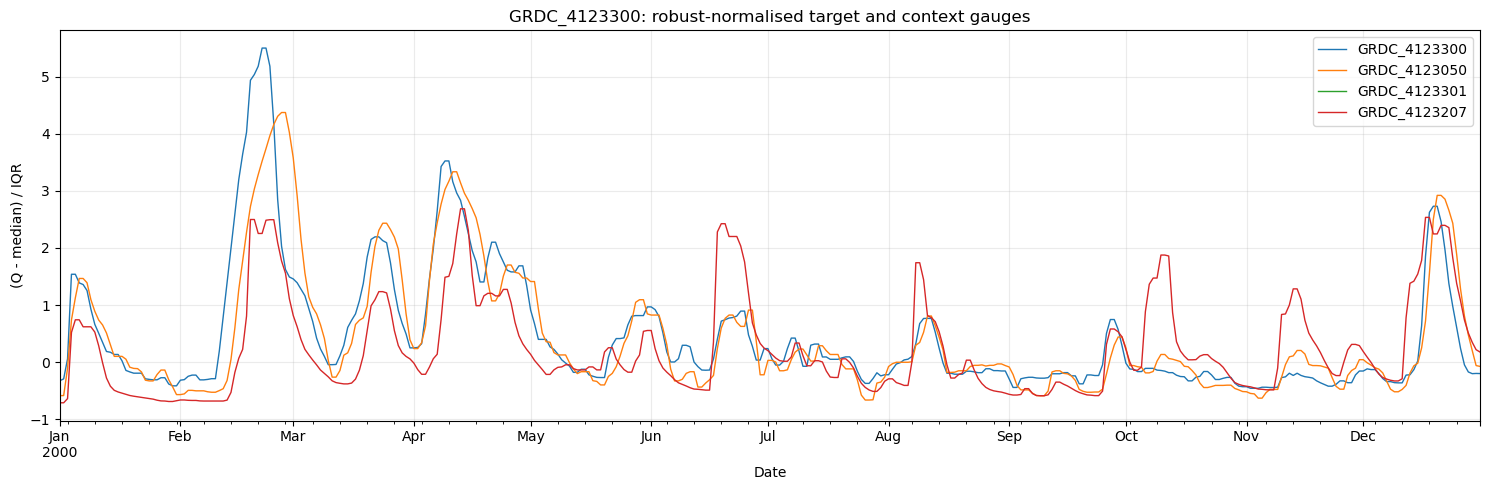

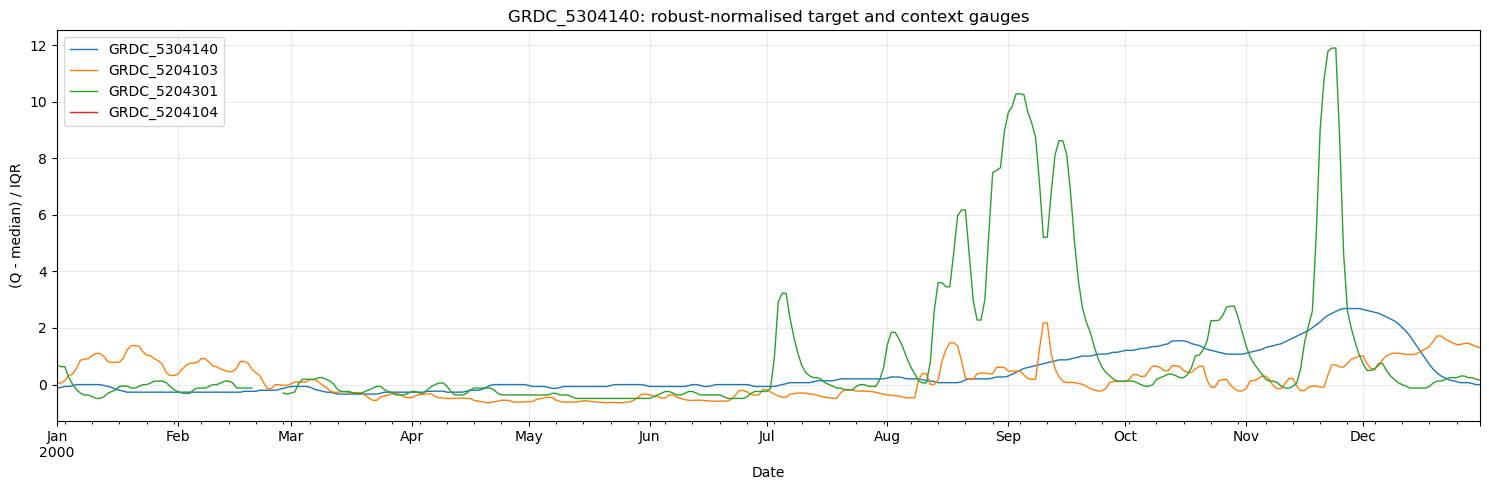

GRDC_6341500: no suitable context candidates.


In [17]:
PLOT_START = "2000-01-01"
PLOT_END = "2000-12-31"


def plot_context_period(target_id, start=PLOT_START, end=PLOT_END):
    if not ROW_ORDER_CONFIRMED:
        raise RuntimeError("The NetCDF station mapping was not validated.")

    candidates = candidate_results[target_id]["candidates"]
    if candidates.empty:
        print(f"{target_id}: no suitable context candidates.")
        return

    plot_frame = {
        target_id: robust_normalise(
            series_for_gauge(target_id).loc[start:end]
        )
    }

    for candidate_id in candidates["gauge_id"].head(3):
        plot_frame[candidate_id] = robust_normalise(
            series_for_gauge(candidate_id).loc[start:end]
        )

    plot_frame = pd.DataFrame(plot_frame)

    ax = plot_frame.rolling(
        3,
        center=True,
        min_periods=1,
    ).median().plot(figsize=(15, 5), linewidth=1.0)

    ax.set_title(
        f"{target_id}: robust-normalised target and context gauges"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("(Q - median) / IQR")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


if ROW_ORDER_CONFIRMED:
    for target_id in TARGET_IDS:
        plot_context_period(target_id)


## Prototype interpretation

For today's Layer 3 prototype:

- **Strong context:** at least two same-river candidates are available.
- **Moderate context:** one same-river candidate plus another same-catchment candidate.
- **Weak context:** at least two same-catchment candidates, but none on the same named river.
- **Limited context:** only one candidate exists, so no majority agreement is possible.
- **Unavailable:** no suitable same-catchment candidate exists.

`Unavailable` is a valid output, not a data-quality flag.
